In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [30]:
orders = pd.read_csv(r"..\Blinkit_datasets\blinkit_orders.csv")
orders_items = pd.read_csv(r"..\Blinkit_datasets\blinkit_order_items.csv")
delivery = pd.read_csv(r"..\Blinkit_datasets\blinkit_delivery_performance.csv")
feedback = pd.read_csv(r"..\Blinkit_datasets\blinkit_customer_feedback.csv")

In [31]:
delivery.duplicated().sum()   

np.int64(0)

In [32]:
delivery.isna().sum()

order_id                    0
delivery_partner_id         0
promised_time               0
actual_time                 0
delivery_time_minutes       0
distance_km                 0
delivery_status             0
reasons_if_delayed       1902
dtype: int64

In [33]:
delivery.columns

Index(['order_id', 'delivery_partner_id', 'promised_time', 'actual_time',
       'delivery_time_minutes', 'distance_km', 'delivery_status',
       'reasons_if_delayed'],
      dtype='object')

In [34]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])

# Delivery analysis

# -------------------------------------------------------------

# Total orders delivered by delivery status

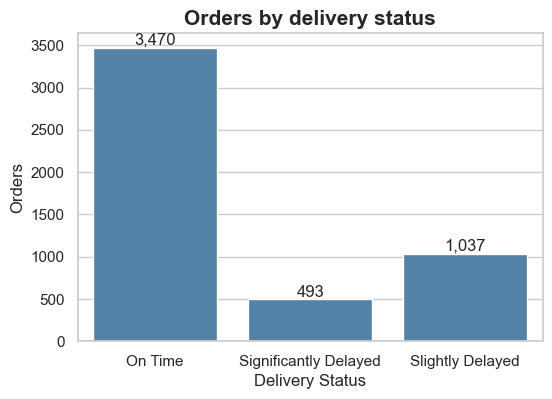

In [35]:
df = orders.groupby('delivery_status', as_index=False)['order_id'].count()

fig, ax = plt.subplots(figsize=(6,4))


sns.barplot(data = df, x = 'delivery_status', y = 'order_id', ax = ax, color='steelblue')

plt.title('Orders by delivery status', fontsize=15, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Orders')
plt.ticklabel_format(style='plain', axis='y')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')


plt.show()

- The majority of orders are delivered on time, with 3,470 orders meeting the promised delivery schedule. However, 1,037 orders experience slight delays and 493 orders are significantly delayed, indicating opportunities to further improve delivery reliability and reduce customer wait times.

# Delivery duration in minutes

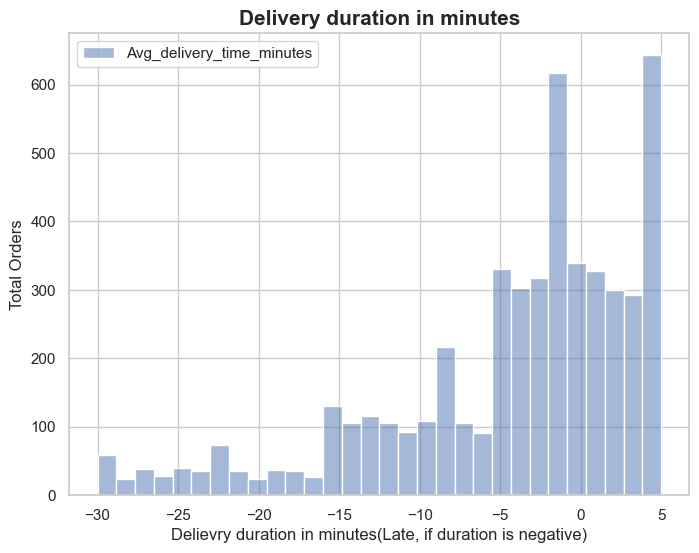

In [36]:
Delivery = pd.DataFrame()
Delivery['Avg_delivery_time_minutes'] = (orders['promised_delivery_time'] - orders['actual_delivery_time']).dt.total_seconds() / 60

plt.figure(figsize=(8,6))
sns.histplot(data = Delivery, bins = 30, kde = False)
plt.title('Delivery duration in minutes', fontsize=15, fontweight='bold')
plt.xlabel('Delievry duration in minutes(Late, if duration is negative)')
plt.ylabel('Total Orders')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

- Most deliveries are completed within a relatively short time window close to the promised delivery time. The distribution is concentrated around small delays and early deliveries, while longer delivery durations occur less frequently, indicating that extreme delays are relatively uncommon

# Boxplot

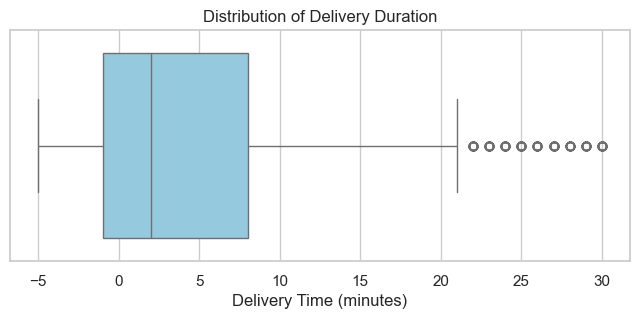

In [37]:
plt.figure(figsize=(8,3))

sns.boxplot(
    x=delivery['delivery_time_minutes'],
    color='skyblue'
)

plt.title('Distribution of Delivery Duration')
plt.xlabel('Delivery Time (minutes)')
plt.show()

- Delivery durations are generally consistent for most orders, with a relatively compact interquartile range. However, several outliers represent deliveries that took significantly longer than typical, suggesting occasional operational issues that should be investigated separately

# Distance vs Delivery time analysis

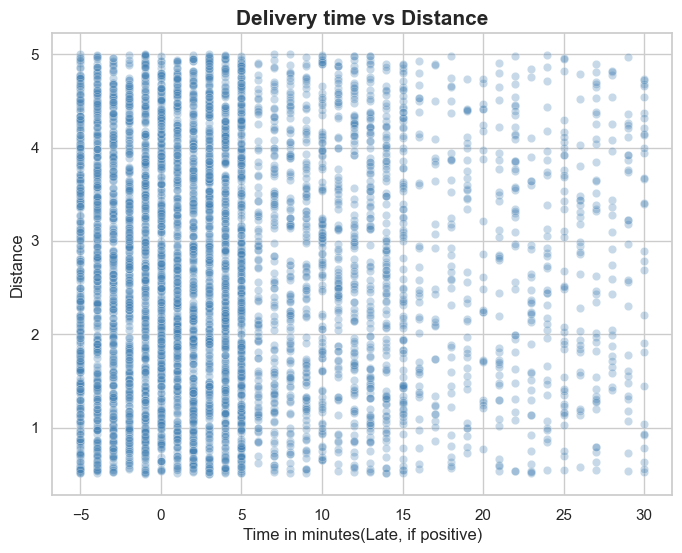

In [38]:
plt.figure(figsize=(8,6))
sns.scatterplot(data = delivery, x = 'delivery_time_minutes', y = 'distance_km', color = 'steelblue', alpha=0.3)

plt.title('Delivery time vs Distance', fontsize=15, fontweight='bold')
plt.xlabel('Time in minutes(Late, if positive)')
plt.ylabel('Distance')

plt.show()

- Delivery time does not show a strong linear relationship with delivery distance. Orders covering similar distances exhibit considerable variation in delivery times, suggesting that factors such as traffic conditions, order preparation time, or delivery partner efficiency may influence delivery performance more than distance alone

# Quantities vs time taken for delivery

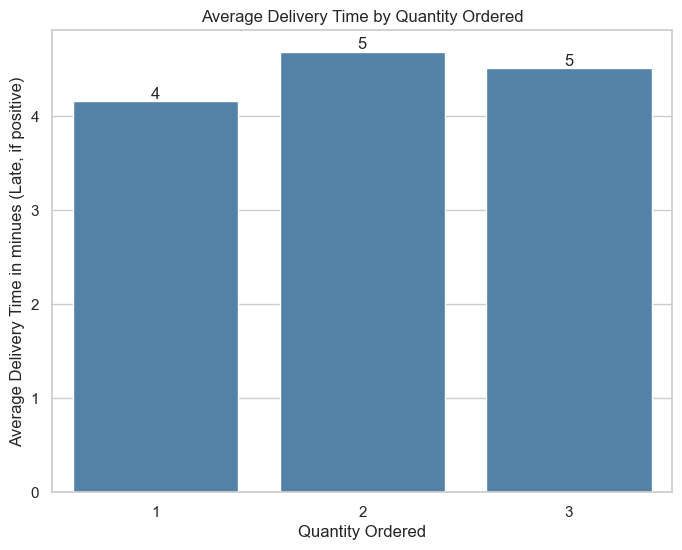

In [39]:
orders_delivery = pd.merge(orders_items, delivery, on='order_id', how='inner')
qty_analysis = orders_delivery.groupby('quantity')['delivery_time_minutes'].mean().reset_index()
plt.figure(figsize=(8,6))

ax = sns.barplot(data=qty_analysis,x='quantity',y='delivery_time_minutes',color='steelblue')

plt.title('Average Delivery Time by Quantity Ordered')
plt.xlabel('Quantity Ordered')
plt.ylabel('Average Delivery Time in minues (Late, if positive)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

- Average delivery time remains fairly consistent across different order quantities, indicating that increasing the number of items in an order has minimal impact on overall delivery duration

# Ordered amount vs time taken in minutes

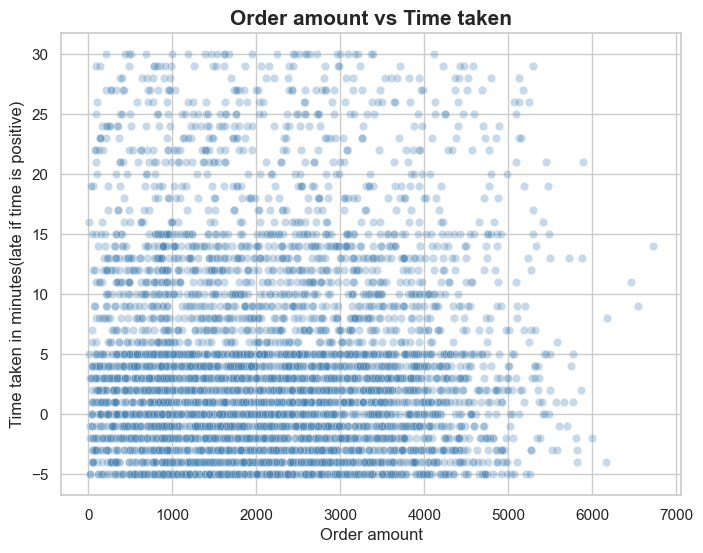

In [40]:
orders_delivery_2 = pd.merge(orders, delivery, on='order_id', how='inner')

plt.figure(figsize=(8,6))
sns.scatterplot(data = orders_delivery_2, x = 'order_total', y = 'delivery_time_minutes', color = 'steelblue', alpha=0.3)

plt.title('Order amount vs Time taken', fontsize=15, fontweight='bold')
plt.xlabel('Order amount')
plt.ylabel('Time taken in minutes(late if time is positive)')

plt.show()

- Higher-value orders do not consistently require longer delivery times. Delivery duration varies across all order values, indicating that order amount alone is not a significant factor affecting delivery performance

# Products associated with late deliveries

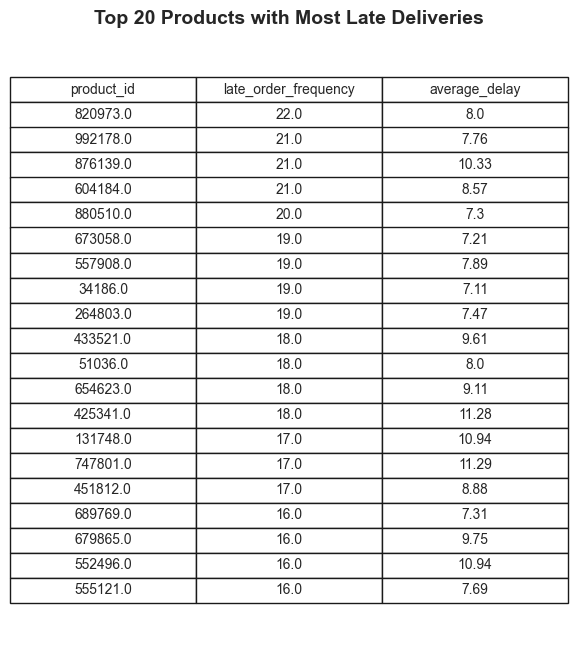

In [41]:
delivery['is_late'] = (delivery['actual_time'] > delivery['promised_time'])
late_orders = delivery[delivery['is_late']][['order_id', 'delivery_time_minutes']]

late_items = orders_items.merge(late_orders, on='order_id', how='inner')

late_product_analysis = (late_items.groupby('product_id').agg(late_order_frequency=('product_id', 'size'), average_delay=('delivery_time_minutes', 'mean')).reset_index().sort_values('late_order_frequency', ascending=False))
late_product_analysis = late_product_analysis.head(20)

fig, ax = plt.subplots(figsize=(6,8))
ax.axis('off')

table = ax.table(cellText=late_product_analysis.round({'average_delay': 2}).values,colLabels=late_product_analysis.columns,cellLoc='center',loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title('Top 20 Products with Most Late Deliveries', fontsize=14, fontweight='bold')
plt.show()

# Delivery partners associated with late deliveries

In [42]:
orders[orders['actual_delivery_time']>orders['promised_delivery_time']].groupby('delivery_partner_id').size()

delivery_partner_id
43       1
66       1
70       1
102      1
158      1
        ..
99889    1
99898    1
99899    1
99958    1
99968    1
Length: 3098, dtype: int64

# Reasons for later deliveries

In [43]:
reasons = delivery[delivery['actual_time']>delivery['promised_time']].groupby('reasons_if_delayed', as_index=False).size()
reasons.columns=['Delay_reason', 'Count']
reasons.style.hide(axis='index')

Delay_reason,Count
Traffic,3098


In [44]:
delivery.columns

Index(['order_id', 'delivery_partner_id', 'promised_time', 'actual_time',
       'delivery_time_minutes', 'distance_km', 'delivery_status',
       'reasons_if_delayed', 'is_late'],
      dtype='object')

# Delivery duration by weekday

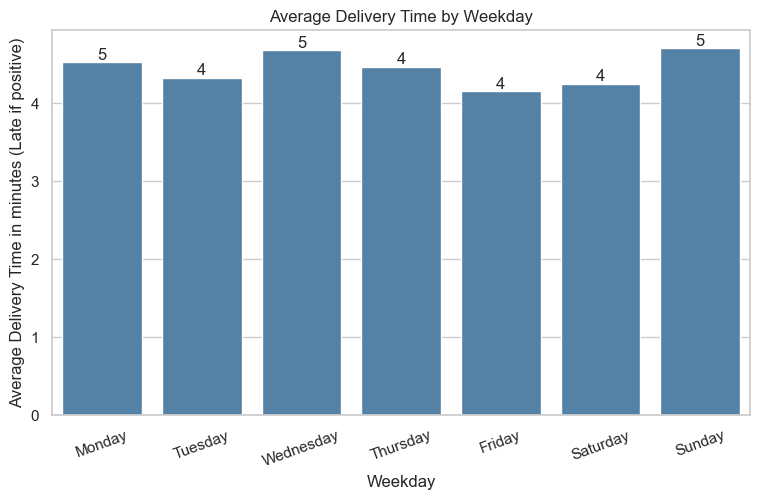

In [45]:
delivery['actual_time'] = pd.to_datetime(delivery['actual_time'])
delivery['weekday'] = delivery['actual_time'].dt.day_name()

weekday = delivery.groupby('weekday')['delivery_time_minutes'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).reset_index()

plt.figure(figsize=(9,5))

ax=sns.barplot(data=weekday,x='weekday',y='delivery_time_minutes',color='steelblue')

plt.title('Average Delivery Time by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Delivery Time in minutes (Late if positive)')
plt.xticks(rotation=20)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

- Average delivery time remains relatively consistent throughout the week, with only minor differences between weekdays. This suggests stable operational performance without significant day-specific delivery bottlenecks

# Customer feedback based on delivery

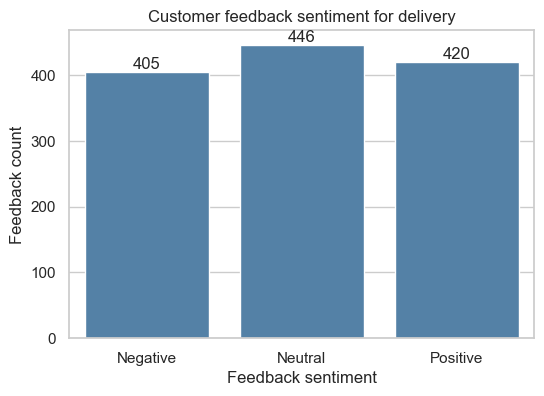

In [48]:
delviry_sentiment = feedback[feedback['feedback_category']=='Delivery'].groupby('sentiment', as_index=False).size()

fig, ax = plt.subplots(figsize=(6, 4))

ax=sns.barplot(data=delviry_sentiment,x='sentiment',y='size',color='steelblue')

plt.title('Customer feedback sentiment for delivery')
plt.xlabel('Feedback sentiment')
plt.ylabel('Feedback count')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

- Customer feedback is relatively balanced across positive, neutral, and negative sentiments, with a slight predominance of neutral feedback. This suggests that while overall service quality is acceptable, there remains scope to convert neutral experiences into positive customer satisfaction

# Customer ratings for delivery

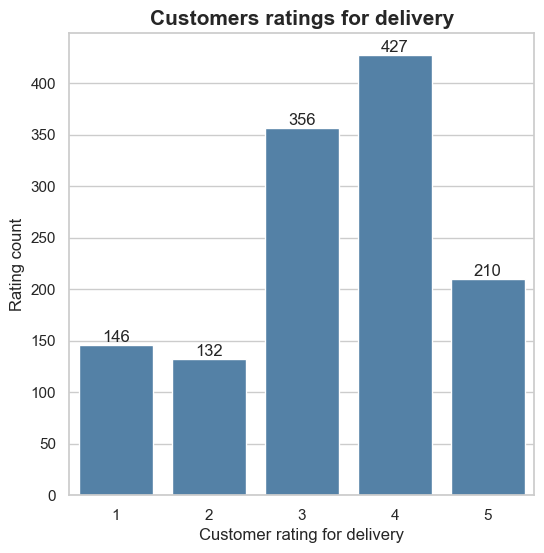

In [49]:
delviry_rating = feedback[feedback['feedback_category']=='Delivery'].groupby('rating', as_index=False).size()

fig, ax = plt.subplots(figsize=(6, 6))

sns.barplot(data=delviry_rating, x='rating', y='size', color='steelblue')

plt.xlabel('Customer rating for delivery')
plt.ylabel('Rating count')
plt.title('Customers ratings for delivery', fontsize=15, fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

- Most customers rate the delivery service between 3 and 4 stars, indicating generally satisfactory delivery performance. However, the presence of lower ratings suggests opportunities to further improve service quality and enhance the overall customer experience

# Overall Business Insights

- Most deliveries are completed on time, demonstrating a generally reliable delivery operation. However, reducing the number of delayed deliveries remains an opportunity to further improve service performance
- Delivery durations are consistent for most orders, with only a small number of extreme delays. These exceptional cases should be investigated to identify operational bottlenecks and improve delivery reliability
- Delivery distance and order value do not exhibit strong relationships with delivery time, suggesting that operational factors such as order preparation, traffic conditions, and delivery execution likely have a greater impact on delivery performance
- Increasing the number of items in an order has only a minimal effect on delivery duration, indicating that current delivery operations effectively handle varying order sizes
- Delivery performance remains stable across all weekdays, demonstrating consistent operational efficiency throughout the week
- Customer feedback is largely neutral to positive, and most customers provide ratings between 3 and 4 stars, indicating satisfactory service while highlighting opportunities to further improve customer satisfaction